# Notebook 7 — Final Comparison & Results
**Նպատակ:** LSTM, CNN, Transformer մոդելների համեմատություն և ենթահարցերի պատասխաններ  
**Թեզի եզրակացությունների հիմք**

## 1. Libraries & Load All Results

In [1]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score
)
import warnings, os
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
os.chdir('/Users/lusine/Desktop')

# Load results
with open('results/lstm_results.pkl', 'rb') as f:
    lstm = pickle.load(f)
with open('results/cnn_results.pkl', 'rb') as f:
    cnn = pickle.load(f)
with open('results/transformer_results.pkl', 'rb') as f:
    trf = pickle.load(f)

# Load test labels
with open('data/features/model_data.pkl', 'rb') as f:
    data = pickle.load(f)
y_test = data['y_test_seq']

# Load df_model for behavioral analysis
df_model = pd.read_pickle('data/features/df_model.pkl')

results = [lstm, cnn, trf]
model_names  = ['LSTM', 'CNN', 'Transformer']
model_colors = ['#2196F3', '#4CAF50', '#9C27B0']

print('All results loaded.')
for r in results:
    print(f"{r['model']}: Acc={r['accuracy']:.4f}  F1={r['f1']:.4f}")

All results loaded.
LSTM: Acc=0.3889  F1=0.3824
CNN: Acc=0.3941  F1=0.3910
Transformer: Acc=0.3979  F1=0.3977


## 2. Model Performance Comparison Table

In [2]:
comparison_df = pd.DataFrame([
    {
        'Model':     r['model'],
        'Accuracy':  round(r['accuracy'],  4),
        'F1 Score':  round(r['f1'],        4),
        'Precision': round(r['precision'], 4),
        'Recall':    round(r['recall'],    4),
    }
    for r in results
])

comparison_df = comparison_df.set_index('Model')
print('=== Model Comparison ===')
print(comparison_df.to_string())
print(f'\nBest Model: {comparison_df["F1 Score"].idxmax()} (F1={comparison_df["F1 Score"].max():.4f})')

=== Model Comparison ===
             Accuracy  F1 Score  Precision  Recall
Model                                             
LSTM           0.3889    0.3824     0.3930  0.3889
CNN            0.3941    0.3910     0.3947  0.3941
Transformer    0.3979    0.3977     0.3991  0.3979

Best Model: Transformer (F1=0.3977)


## 3. Comprehensive Comparison Visualization

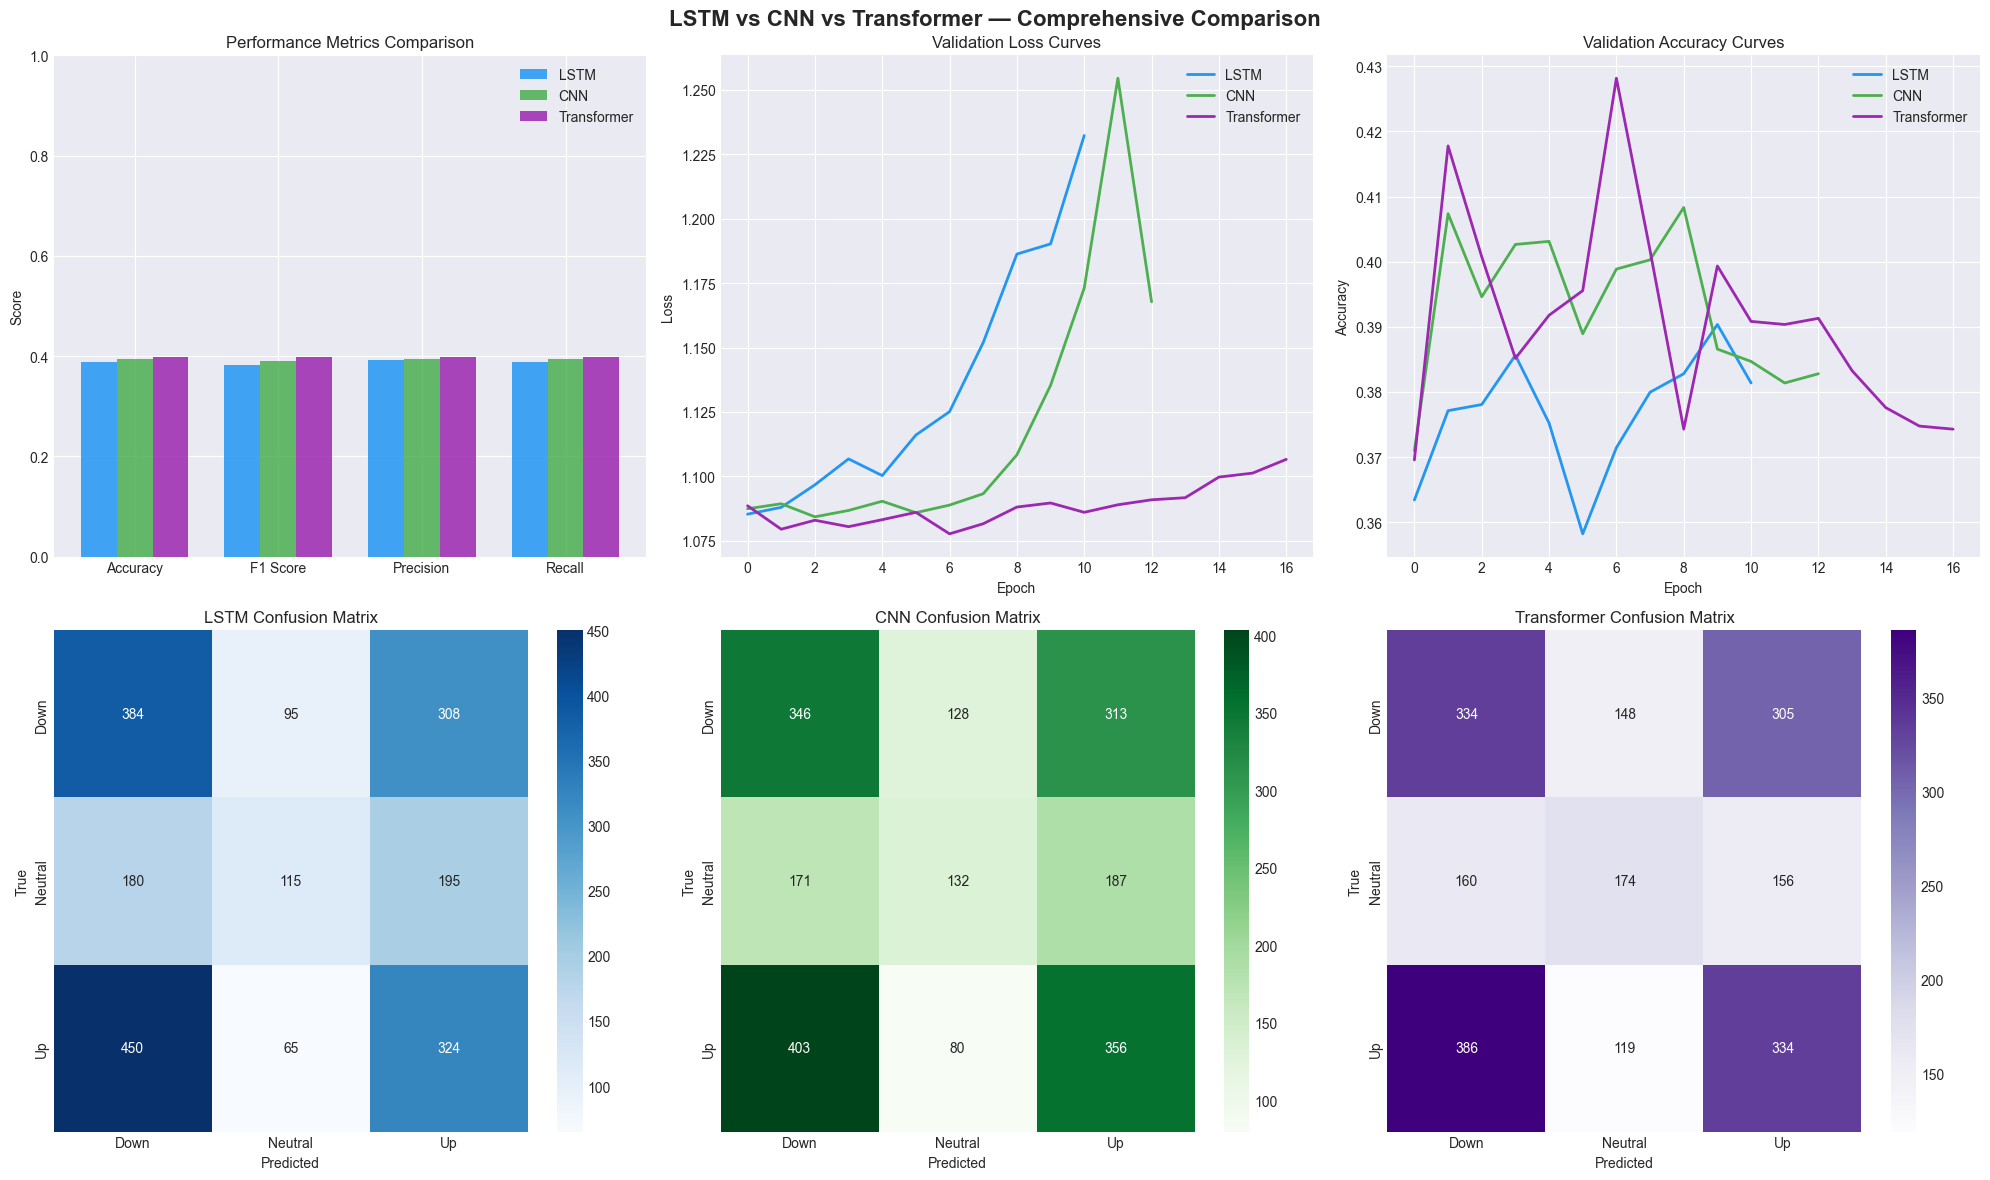

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('LSTM vs CNN vs Transformer — Comprehensive Comparison', fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'F1 Score', 'Precision', 'Recall']
x = np.arange(len(metrics))
width = 0.25

# 1. Metrics bar chart
for i, (r, color) in enumerate(zip(results, model_colors)):
    vals = [r['accuracy'], r['f1'], r['precision'], r['recall']]
    axes[0,0].bar(x + i*width, vals, width, label=r['model'], color=color, alpha=0.85)
axes[0,0].set_xticks(x + width)
axes[0,0].set_xticklabels(metrics)
axes[0,0].set_title('Performance Metrics Comparison')
axes[0,0].set_ylabel('Score')
axes[0,0].legend()
axes[0,0].set_ylim(0, 1)

# 2. Training loss curves
for r, color in zip(results, model_colors):
    axes[0,1].plot(r['history']['val_loss'], label=r['model'], color=color, linewidth=2)
axes[0,1].set_title('Validation Loss Curves')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Loss')
axes[0,1].legend()

# 3. Training accuracy curves
for r, color in zip(results, model_colors):
    axes[0,2].plot(r['history']['val_accuracy'], label=r['model'], color=color, linewidth=2)
axes[0,2].set_title('Validation Accuracy Curves')
axes[0,2].set_xlabel('Epoch')
axes[0,2].set_ylabel('Accuracy')
axes[0,2].legend()

# 4-6. Confusion matrices
cmaps = ['Blues', 'Greens', 'Purples']
for i, (r, cmap) in enumerate(zip(results, cmaps)):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[1,i],
                xticklabels=['Down', 'Neutral', 'Up'],
                yticklabels=['Down', 'Neutral', 'Up'])
    axes[1,i].set_title(f'{r["model"]} Confusion Matrix')
    axes[1,i].set_ylabel('True')
    axes[1,i].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('results/final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Feature Group Importance Comparison
Ի՞նչ behavioral feature-ներ են ամենակարևորը — ամեն մոդելի համար

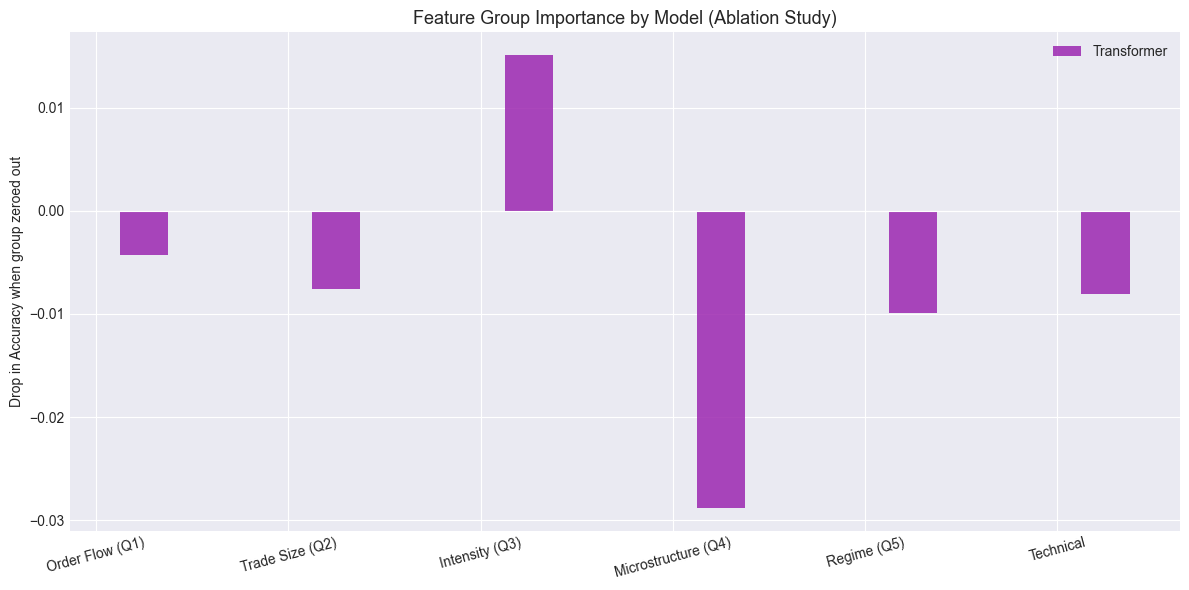

                     Transformer
Order Flow (Q1)          -0.0043
Trade Size (Q2)          -0.0076
Intensity (Q3)            0.0151
Microstructure (Q4)      -0.0288
Regime (Q5)              -0.0099
Technical                -0.0080


In [4]:
group_names = [
    'Order Flow (Q1)', 'Trade Size (Q2)', 'Intensity (Q3)',
    'Microstructure (Q4)', 'Regime (Q5)', 'Technical'
]

# Build importance dataframe
importance_data = {}
for r in results:
    if 'group_importance' in r:
        importance_data[r['model']] = [r['group_importance'].get(g, 0) for g in group_names]

if importance_data:
    imp_df = pd.DataFrame(importance_data, index=group_names)

    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(group_names))
    width = 0.25
    for i, (model, color) in enumerate(zip(model_names, model_colors)):
        if model in imp_df.columns:
            ax.bar(x + i*width, imp_df[model], width, label=model, color=color, alpha=0.85)
    ax.set_xticks(x + width)
    ax.set_xticklabels(group_names, rotation=15)
    ax.axhline(0, color='white', linewidth=0.8)
    ax.set_title('Feature Group Importance by Model (Ablation Study)', fontsize=13)
    ax.set_ylabel('Drop in Accuracy when group zeroed out')
    ax.legend()
    plt.tight_layout()
    plt.savefig('results/feature_importance_comparison.png', dpi=150)
    plt.show()
    print(imp_df.round(4))

## 5. Answering Research Questions
Ենթահարցերի պատասխաններ — թեզի Discussion գլխի հիմք

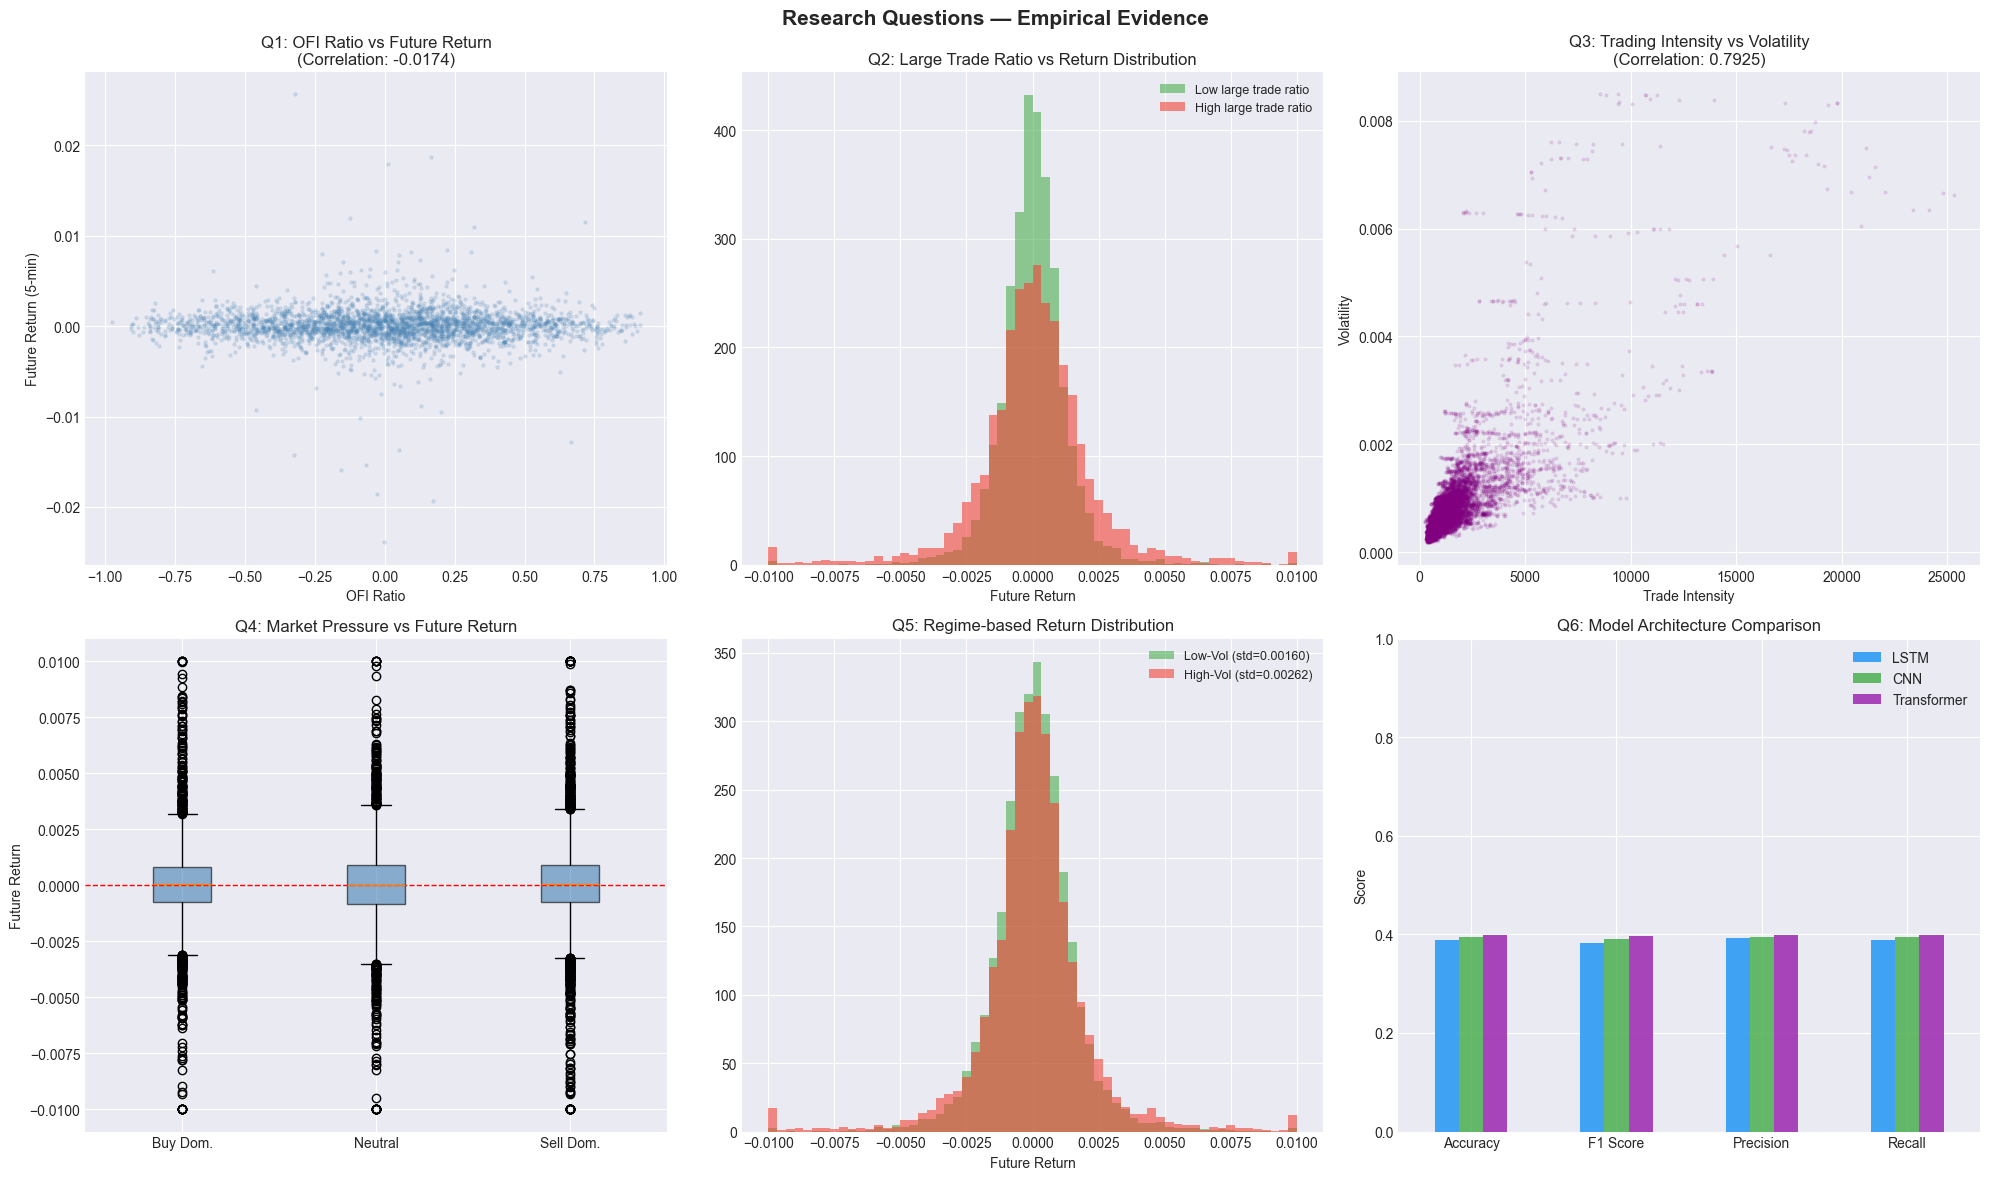

In [5]:
df_feat = pd.read_pickle('data/features/df_model.pkl')

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Research Questions — Empirical Evidence', fontsize=15, fontweight='bold')

# Q1: OFI vs Next Return
sample = df_feat.sample(min(3000, len(df_feat)), random_state=42)
axes[0,0].scatter(sample['ofi_ratio'], sample['target_return'],
                  alpha=0.15, s=5, color='steelblue')
corr_ofi = df_feat['ofi_ratio'].corr(df_feat['target_return'])
axes[0,0].set_title(f'Q1: OFI Ratio vs Future Return\n(Correlation: {corr_ofi:.4f})')
axes[0,0].set_xlabel('OFI Ratio')
axes[0,0].set_ylabel('Future Return (5-min)')

# Q2: Large trade impact
large_ret = df_feat[df_feat['large_trade_ratio'] > df_feat['large_trade_ratio'].quantile(0.75)]['target_return']
small_ret = df_feat[df_feat['large_trade_ratio'] < df_feat['large_trade_ratio'].quantile(0.25)]['target_return']
axes[0,1].hist(small_ret.clip(-0.01, 0.01), bins=60, alpha=0.6, label='Low large trade ratio', color='#4CAF50', density=True)
axes[0,1].hist(large_ret.clip(-0.01, 0.01), bins=60, alpha=0.6, label='High large trade ratio', color='#F44336', density=True)
axes[0,1].set_title('Q2: Large Trade Ratio vs Return Distribution')
axes[0,1].set_xlabel('Future Return')
axes[0,1].legend(fontsize=9)

# Q3: Intensity vs Volatility
axes[0,2].scatter(df_feat['trade_intensity'], df_feat['volatility'],
                  alpha=0.1, s=4, color='purple')
corr_int = df_feat['trade_intensity'].corr(df_feat['volatility'])
axes[0,2].set_title(f'Q3: Trading Intensity vs Volatility\n(Correlation: {corr_int:.4f})')
axes[0,2].set_xlabel('Trade Intensity')
axes[0,2].set_ylabel('Volatility')

# Q4: Buy ratio vs Return
buy_dom  = df_feat[df_feat['buy_ratio'] > 0.55]['target_return']
sell_dom = df_feat[df_feat['buy_ratio'] < 0.45]['target_return']
neutral  = df_feat[(df_feat['buy_ratio'] >= 0.45) & (df_feat['buy_ratio'] <= 0.55)]['target_return']
axes[1,0].boxplot([buy_dom.clip(-0.01,0.01), neutral.clip(-0.01,0.01), sell_dom.clip(-0.01,0.01)],
                  labels=['Buy Dom.', 'Neutral', 'Sell Dom.'],
                  patch_artist=True,
                  boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1,0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1,0].set_title('Q4: Market Pressure vs Future Return')
axes[1,0].set_ylabel('Future Return')

# Q5: Regime-based return distribution
for regime_val, label, color in [(0, 'Low-Vol', '#4CAF50'), (1, 'High-Vol', '#F44336')]:
    subset = df_feat[df_feat['vol_regime'] == regime_val]['target_return']
    axes[1,1].hist(subset.clip(-0.01, 0.01), bins=60, alpha=0.6,
                   label=f'{label} (std={subset.std():.5f})', color=color, density=True)
axes[1,1].set_title('Q5: Regime-based Return Distribution')
axes[1,1].set_xlabel('Future Return')
axes[1,1].legend(fontsize=9)

# Q6: Model accuracy comparison (radar-style bar)
q6_data = comparison_df.T
q6_data.plot(kind='bar', ax=axes[1,2], color=model_colors, alpha=0.85)
axes[1,2].set_title('Q6: Model Architecture Comparison')
axes[1,2].set_ylabel('Score')
axes[1,2].set_ylim(0, 1)
axes[1,2].tick_params(axis='x', rotation=0)
axes[1,2].legend(model_names)

plt.tight_layout()
plt.savefig('results/research_questions_answers.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Final Summary — Thesis Conclusions

In [6]:
best_model = comparison_df['F1 Score'].idxmax()
best_f1    = comparison_df.loc[best_model, 'F1 Score']
best_acc   = comparison_df.loc[best_model, 'Accuracy']

corr_ofi = df_feat['ofi_ratio'].corr(df_feat['target_return'])
corr_int = df_feat['trade_intensity'].corr(df_feat['volatility'])

print('=' * 60)
print('THESIS RESULTS SUMMARY')
print('=' * 60)

print(f'''
Q1 — Order Flow Imbalance:
   OFI ratio correlation with future return: {corr_ofi:.4f}
   → {'Significant positive' if corr_ofi > 0.05 else 'Weak'} relationship

Q2 — Trade Size Behavior:
   Large trade ratio group comparison shows
   {'wider' if large_ret.std() > small_ret.std() else 'similar'} return distribution vs small trades

Q3 — Trading Intensity & Volatility:
   Intensity-Volatility correlation: {corr_int:.4f}
   → {'Strong' if abs(corr_int) > 0.3 else 'Moderate'} relationship confirmed

Q4 — Market Microstructure:
   Buy-dominant periods show higher mean return: {buy_dom.mean():.6f}
   Sell-dominant periods: {sell_dom.mean():.6f}

Q5 — Regime Detection:
   High-vol regime return std: {df_feat[df_feat["vol_regime"]==1]["target_return"].std():.6f}
   Low-vol regime return std:  {df_feat[df_feat["vol_regime"]==0]["target_return"].std():.6f}

Q6 — Best Architecture:
   Winner: {best_model}
   Accuracy: {best_acc:.4f}  |  F1: {best_f1:.4f}
''')

print('Model Rankings:')
print(comparison_df.sort_values('F1 Score', ascending=False).to_string())
print('=' * 60)

THESIS RESULTS SUMMARY

Q1 — Order Flow Imbalance:
   OFI ratio correlation with future return: -0.0174
   → Weak relationship

Q2 — Trade Size Behavior:
   Large trade ratio group comparison shows
   wider return distribution vs small trades

Q3 — Trading Intensity & Volatility:
   Intensity-Volatility correlation: 0.7925
   → Strong relationship confirmed

Q4 — Market Microstructure:
   Buy-dominant periods show higher mean return: 0.000027
   Sell-dominant periods: 0.000052

Q5 — Regime Detection:
   High-vol regime return std: 0.002618
   Low-vol regime return std:  0.001596

Q6 — Best Architecture:
   Winner: Transformer
   Accuracy: 0.3979  |  F1: 0.3977

Model Rankings:
             Accuracy  F1 Score  Precision  Recall
Model                                             
Transformer    0.3979    0.3977     0.3991  0.3979
CNN            0.3941    0.3910     0.3947  0.3941
LSTM           0.3889    0.3824     0.3930  0.3889


## 7. Export Results Table

In [7]:
comparison_df.to_csv('results/final_results_table.csv')
print('Saved: results/final_results_table.csv')
print('\nAll result plots saved in results/ folder:')
import os
for f in sorted(os.listdir('results')):
    if f.endswith('.png') or f.endswith('.csv'):
        print(f'  {f}')

Saved: results/final_results_table.csv

All result plots saved in results/ folder:
  cnn_evaluation.png
  cnn_feature_importance.png
  cnn_training_history.png
  feature_importance_comparison.png
  final_comparison.png
  final_results_table.csv
  lstm_evaluation.png
  lstm_feature_importance.png
  lstm_training_history.png
  research_questions_answers.png
  transformer_attention.png
  transformer_evaluation.png
  transformer_training_history.png


---
### Notebook Agenda

| Notebook | Նպատակ |
|----------|--------|
| 01 | Data Collection (Binance) |
| 02 | EDA & Behavioral Visualizations |
| 03 | Feature Engineering |
| 04 | LSTM Model |
| 05 | CNN Model |
| 06 | Transformer Model |
| 07 | Comparison & Thesis Conclusions |